# VISION TRANSFORMER ARCHITECTURE FOR REFERENCE

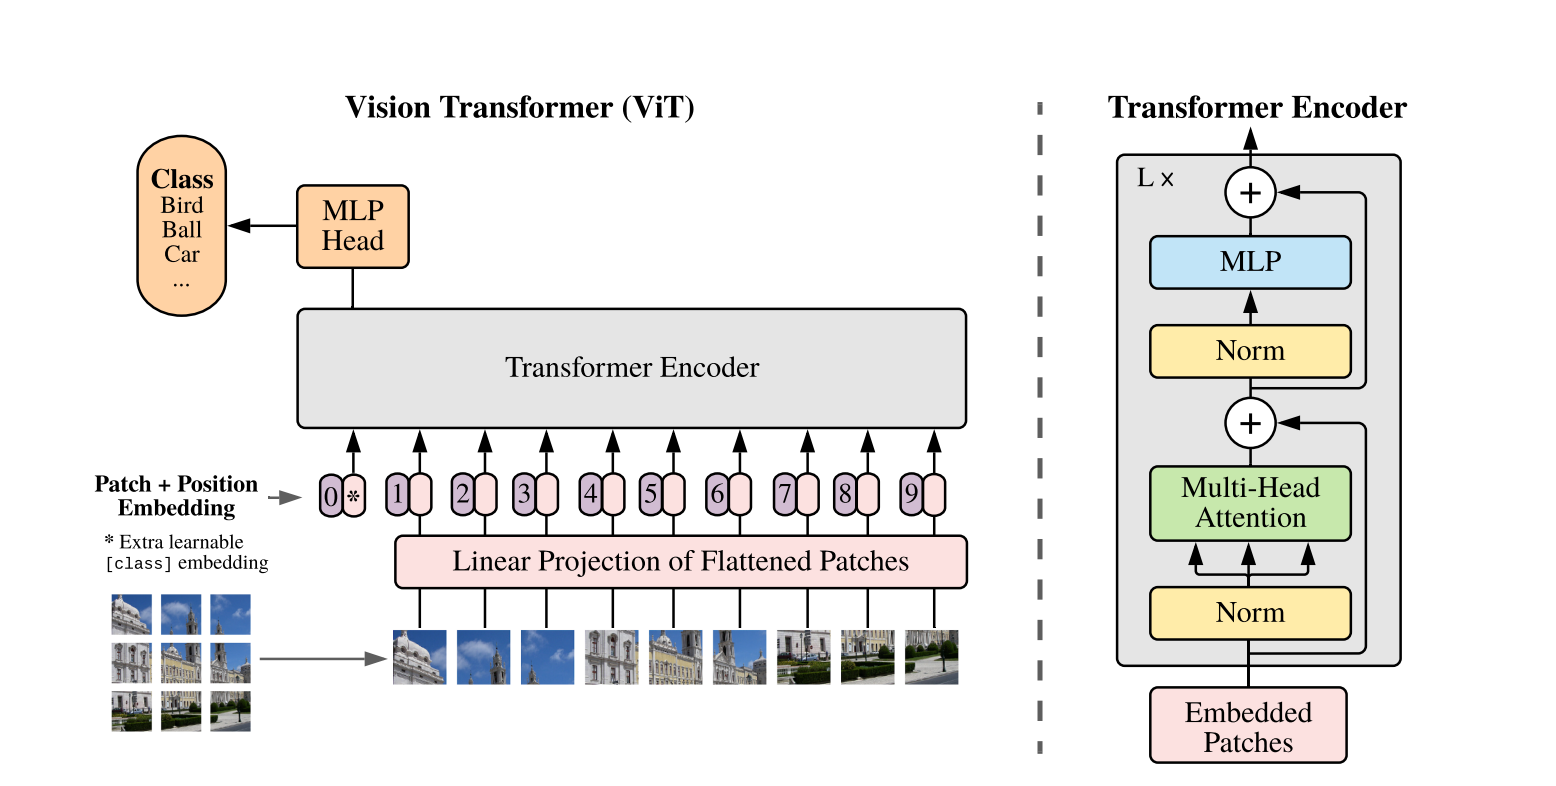

#  IMPORT MODULES AND PREPARE DATA

In [1]:
import torch #Core library
import torch.nn as nn # Neural network library
from torchvision import datasets , transforms #datasets -> library of famous , common datasets (eg cifar , mnist , etc.
                                              #transforms -> converting image to a tensor
from torch.utils.data import DataLoader  # atching the input data

In [2]:
#Procure the datasets
train_mnist = datasets.MNIST(root = r"C:\Users\Srihari Srivathsan\OneDrive\Documents\PyTorch Programs\Deep Learning With PyTorch\Datasets" ,
                             train = True ,
                             download = True ,
                             transform = transforms.Compose([transforms.ToTensor()]))
val_mnist = datasets.MNIST(root = r"C:\Users\Srihari Srivathsan\OneDrive\Documents\PyTorch Programs\Deep Learning With PyTorch\Datasets" ,
                           train = False ,
                           download = True ,
                           transform = transforms.Compose([transforms.ToTensor()]))

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


In [3]:
#Batch the training and validation data
train_loader = DataLoader(train_mnist , batch_size = 64 , shuffle = True)
val_loader = DataLoader(val_mnist , batch_size = 64 , shuffle = True)
len(train_loader) , len(val_loader)

(938, 157)

# MODEL CLASS

In [4]:
cfg = {
        "n_classes" : 10 ,
        "patch_size" : 7 ,
        "n_patches" : 16 ,
        "batch_size" : 64 ,
        "input_channels" : 1 ,
        "emb_dim" : 1024 ,
        "n_heads" : 4 ,
        "n_layers" : 4 ,
        "lr" : 0.001 ,
        "drop_rate" : 0.2 ,
        "n_epochs" : 5 ,
        "qkv_bias" : False
      } # MODEL CONFIGURATION --> GLOBAL

In [5]:
class VisionTransformer(nn.Module) :
    def __init__ (self) :
        super().__init__() #to inherit nn.Module methods (subclassing)

        self.patch_embedding = PatchEmbedding() #
        self.class_embedding = nn.Parameter(torch.randn( 1 , 1 , cfg["emb_dim"]))
        self.position_embedding = nn.Parameter(torch.randn(1 , cfg["n_patches"] + 1 , cfg["emb_dim"]))

        self.dropout_1 = nn.Dropout(p = cfg["drop_rate"])

        self.transformer_encoders = nn.Sequential(*[TransformerEncoder() for _ in range(cfg["n_layers"])]) #

        self.out_mlp_head = OutMLPHead() #

    def forward(self , x) :

        #Embedding
        x = self.patch_embedding(x)
        b = x.size(0)
        class_embeddings = self.class_embedding.expand((b , - 1 , - 1))
        x = torch.cat((class_embeddings , x) , dim = 1)
        x = x + self.position_embedding

        #Transformer Encoder
        x = self.transformer_encoders(x)

        #Out MLP
        x = x[: , 0]
        x = self.out_mlp_head(x)

        return x


# COMPONENTS OF THE VISION TRANSFORMER

In [6]:
class PatchEmbedding(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.patch_embedding = nn.Conv2d(cfg["input_channels"] , cfg["emb_dim"] , kernel_size = cfg["patch_size"] , stride = cfg["patch_size"])
    def forward(self , x) :
        x = self.patch_embedding(x)
        x = x.flatten(2)
        x = x.transpose(1,2)

        return x

In [27]:
class LayerNorm (nn.Module) :
    def __init__(self) :
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(cfg["emb_dim"]))
        self.shift = nn.Parameter(torch.zeros(cfg["emb_dim"]))
    def forward(self , x) :
        mean = torch.mean(x , dim = - 1 , keepdim = True)
        std = torch.std(x , dim = - 1 , keepdim = True)

        x = (x - mean) / std

        return self.scale * x + self.shift

In [28]:
class MultiHeadAttention (nn.Module) :
    def __init__(self , d_in , d_out , n_heads ,  qkv_bias) :
        super().__init__()
        assert (d_out % n_heads == 0) , "d_out must be divisible by n_heads"
        self.d_out = d_out
        self.n_heads = n_heads
        self.head_dim = self.d_out // self.n_heads
        self.qkv_bias = qkv_bias

        self.W_query = nn.Linear(d_in , self.d_out , bias = self.qkv_bias)
        self.W_key = nn.Linear(d_in , self.d_out , bias = self.qkv_bias)
        self.W_value = nn.Linear(d_in , self.d_out , bias = self.qkv_bias)

    def forward(self , x) :

        batch_size , n_patches , d_in = x.shape
        keys , queries , values = self.W_key(x) , self.W_query(x) , self.W_value(x)


        keys = keys.view(batch_size , n_patches , self.n_heads , self.head_dim).transpose(1,2)
        queries = queries.view(batch_size , n_patches , self.n_heads , self.head_dim).transpose(1,2)
        values = values.view(batch_size , n_patches , self.n_heads , self.head_dim).transpose(1,2)

        attn_scores = queries @ keys.transpose(2 , 3)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5 , dim = -1)

        context_vec = attn_weights @ values

        context_vec = context_vec.transpose(1,2)
        context_vec = context_vec.contiguous().view(batch_size , n_patches , self.d_out)

        return context_vec

In [29]:
class GeLU(nn.Module) :
    def __init__(self) :
        super().__init__()

    def forward(self , x) :
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [30]:
class EncoderMLP(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.linear_1 = nn.Linear(cfg["emb_dim"] , 4 * cfg["emb_dim"])
        self.gelu = GeLU()
        self.linear_2 = nn.Linear(4 * cfg["emb_dim"] , cfg["emb_dim"])
        self.dropout = nn.Dropout(p = cfg["drop_rate"])

    def forward(self , x) :

        x = self.linear_1(x)
        x=self.gelu(x)
        x=self.linear_2(x)
        x = self.dropout(x)

        return x


In [31]:
class TransformerEncoder (nn.Module) :
    def __init__(self) :
        super().__init__()
        self.pre_layer_norm_1 = LayerNorm()
        self.attention = MultiHeadAttention(d_in = cfg["emb_dim"] ,
                                            d_out = cfg["emb_dim"] ,
                                            n_heads = cfg["n_heads"] ,
                                            qkv_bias = False)
        self.pre_layer_norm_2 = LayerNorm()
        self.mlp = EncoderMLP()
        self.dropout = nn.Dropout(p = cfg["drop_rate"])

    def forward (self , x) :

        #MHA
        shortcut = x
        x = self.pre_layer_norm_1(x)
        x = self.attention(x)
        x = x + shortcut

        #MLP
        shortcut = x
        x = self.pre_layer_norm_2(x)
        x = self.mlp(x)
        x = self.dropout(x)
        x = x + shortcut

        return x



In [32]:
class OutMLPHead(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.layer_norm = LayerNorm()
        self.linear = nn.Linear(cfg["emb_dim"] , cfg["n_classes"])

    def forward(self , x) :
        x = self.layer_norm(x)
        x = self.linear(x)

        return x


In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VisionTransformer()
optimizer = torch.optim.Adam(model.parameters() , lr = cfg["lr"])
loss_class = nn.CrossEntropyLoss()
epochs = 5

In [34]:
for epoch in range(epochs):
    model.train()

    total_loss = 0.0
    correct_epoch = 0
    total_epoch = 0

    print(f"\nEpoch {epoch + 1}")

    for batch_idx, (images, labels) in enumerate(train_loader):

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images).to(device = device)

        loss = loss_class(outputs, labels)

        loss.backward()

        optimizer.step()

        # Statistics
        total_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct = (preds == labels).sum().item()

        correct_epoch += correct
        total_epoch += labels.size(0)

        batch_accuracy = 100.0 * correct / labels.size(0)

        if batch_idx % 100 == 0:
            print(f"Batch {batch_idx:4d} | Loss: {loss.item():.4f} | Batch Accuracy: {batch_accuracy:.2f}%")

    epoch_loss = total_loss / len(train_loader)
    epoch_accuracy = 100.0 * correct_epoch / total_epoch

    print(f"Epoch {epoch + 1} Summary")
    print(f"Average Loss: {epoch_loss:.4f}")
    print(f"Accuracy: {epoch_accuracy:.2f}%")


Epoch 1
Batch    0 | Loss: 2.4912 | Batch Accuracy: 6.25%
Batch  100 | Loss: 2.2991 | Batch Accuracy: 7.81%
Batch  200 | Loss: 1.7191 | Batch Accuracy: 37.50%
Batch  300 | Loss: 1.2224 | Batch Accuracy: 50.00%
Batch  400 | Loss: 0.9206 | Batch Accuracy: 73.44%
Batch  500 | Loss: 0.9384 | Batch Accuracy: 60.94%
Batch  600 | Loss: 1.1662 | Batch Accuracy: 70.31%
Batch  700 | Loss: 0.8279 | Batch Accuracy: 78.12%
Batch  800 | Loss: 0.9075 | Batch Accuracy: 68.75%
Batch  900 | Loss: 0.7124 | Batch Accuracy: 73.44%
Epoch 1 Summary
Average Loss: 1.2907
Accuracy: 54.47%

Epoch 2
Batch    0 | Loss: 0.8947 | Batch Accuracy: 67.19%
Batch  100 | Loss: 0.7891 | Batch Accuracy: 67.19%
Batch  200 | Loss: 0.8081 | Batch Accuracy: 65.62%
Batch  300 | Loss: 0.8542 | Batch Accuracy: 68.75%
Batch  400 | Loss: 0.7276 | Batch Accuracy: 78.12%
Batch  500 | Loss: 0.5982 | Batch Accuracy: 81.25%
Batch  600 | Loss: 0.5836 | Batch Accuracy: 82.81%
Batch  700 | Loss: 0.5476 | Batch Accuracy: 84.38%
Batch  800 |

In [35]:
torch.save({"model_state_dict" : model.state_dict() , "optimizer_state_dict" : optimizer.state_dict()} , "model_weights_vit.pth")
checkpoint = torch.load("model_weights_vit.pth")

test_model = VisionTransformer()
test_model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(test_model.parameters())
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

print("Loaded successfully!")

Loaded successfully!


In [38]:
parameters = sum([p.numel() for p in model.parameters() if p.requires_grad == True])

46

In [42]:
with torch.no_grad() :
  total = 0
  correct = 0
  for batch_idx, (images, labels) in enumerate(val_loader):

        images, labels = images.to(device), labels.to(device)
        outputs = model(images).to(device = device)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
  accuracy = 100 * correct / total
print(accuracy)

85.1


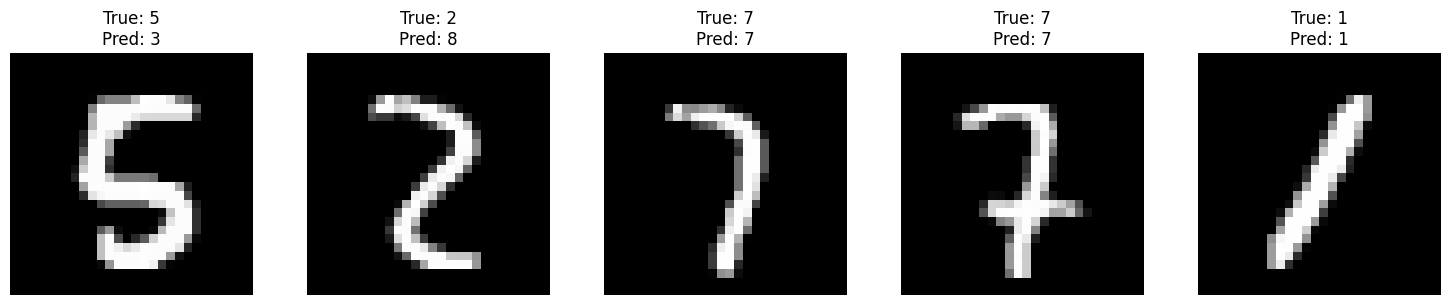

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Set the model to evaluation mode
model.eval()

# Get 5 random indices from the validation dataset
num_samples = 5
random_indices = np.random.choice(len(val_mnist), num_samples, replace=False)

fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for i, idx in enumerate(random_indices):
    image, true_label = val_mnist[idx]

    # Move image to device and add a batch dimension
    image = image.to(device).unsqueeze(0)

    # Get model prediction
    with torch.no_grad():
        output = model(image)
        predicted_label = output.argmax(dim=1).item()

    # Plot the image
    axes[i].imshow(image.cpu().squeeze().numpy(), cmap='gray')
    axes[i].set_title(f"True: {true_label}\nPred: {predicted_label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()